In [1]:
from google.colab import files

# kaggle.jsonをアップロード
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
import os

# ディレクトリの作成
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# 権限の設定
!chmod 600 ~/.kaggle/kaggle.json

# 正しく配置されたか確認
!ls -l ~/.kaggle/kaggle.json

-rw------- 1 root root 71 Apr 28 11:02 /root/.kaggle/kaggle.json


In [3]:
# Store Sales データのダウンロード
!kaggle competitions download -c store-sales-time-series-forecasting

100% 21.4M/21.4M [00:00<00:00, 196MB/s]



In [4]:
import zipfile
import os

# ディレクトリの作成
if not os.path.exists('./store_sales_data'):
    os.makedirs('./store_sales_data')

# 解凍
with zipfile.ZipFile('store-sales-time-series-forecasting.zip', 'r') as zip_ref:
    zip_ref.extractall('./store_sales_data')

# 解凍されたファイル一覧を確認
!ls ./store_sales_data

holidays_events.csv  sample_submission.csv  test.csv   transactions.csv
oil.csv		     stores.csv		    train.csv


In [5]:
import pandas as pd

# メインの売上データ
# 日付をパースして読み込む
train_sales = pd.read_csv('./store_sales_data/train.csv', parse_dates=['date'])

# 店舗情報（都市やタイプが含まれる）
stores_df = pd.read_csv('./store_sales_data/stores.csv')

# 2つのデータを store_nbr（店舗番号）をキーに結合
df = pd.merge(train_sales, stores_df, on='store_nbr', how='left')

# 構造の確認
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 10 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   city         object        
 7   state        object        
 8   type         object        
 9   cluster      int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 228.9+ MB
None


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


In [6]:
# 分析をシンプルにするため、2017年のみを抽出
df_2017 = df[df['date'].dt.year == 2017].copy()

# 都市ごとの1日の総売上を算出
city_sales = df_2017.groupby(['date', 'city'])['sales'].sum().reset_index()

# データの一部を表示
print(city_sales.head())

        date      city  sales
0 2017-01-01    Ambato    0.0
1 2017-01-01  Babahoyo    0.0
2 2017-01-01   Cayambe    0.0
3 2017-01-01    Cuenca    0.0
4 2017-01-01     Daule    0.0


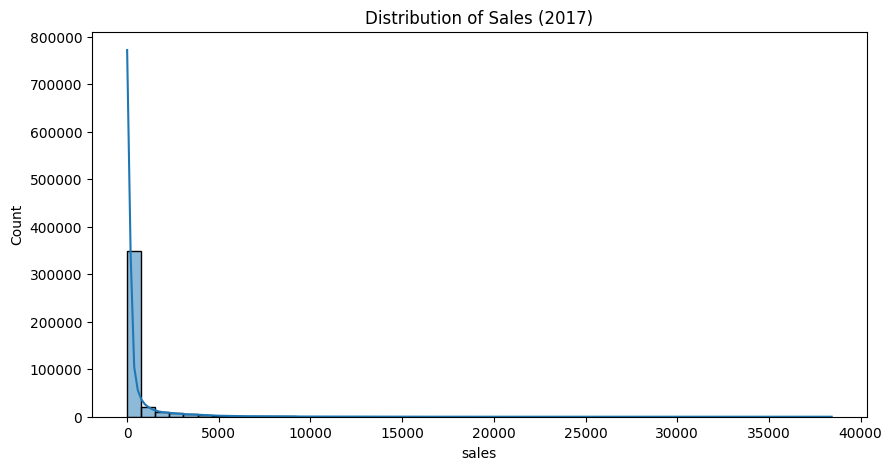

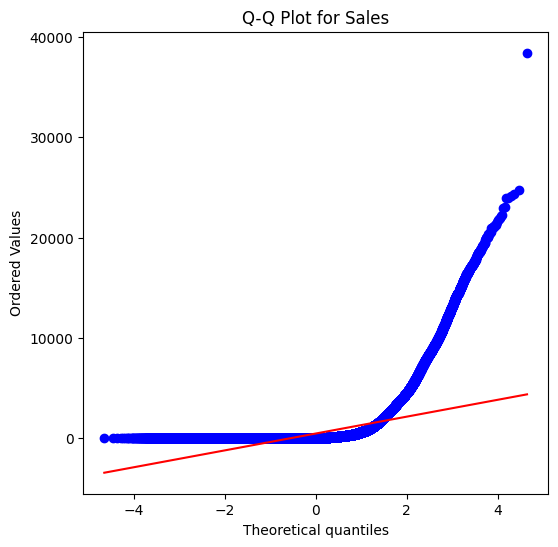

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. ヒストグラムで視覚的に確認
plt.figure(figsize=(10, 5))
sns.histplot(df_2017['sales'], kde=True, bins=50)
plt.title('Distribution of Sales (2017)')
plt.show()

# 2. Q-Qプロット（正規確率プロット）
plt.figure(figsize=(6, 6))
stats.probplot(df_2017['sales'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Sales')
plt.show()

In [8]:
import numpy as np

# 2017年の全店舗の平均売上に対する95%信頼区間
mean_sales = df_2017['sales'].mean()
std_error = stats.sem(df_2017['sales']) # 標準誤差

# 信頼区間の計算 (1.96は95%信頼区間の係数)
ci_lower = mean_sales - 1.96 * std_error
ci_upper = mean_sales + 1.96 * std_error

print(f"2017年 平均売上: {mean_sales:.2f}")
print(f"95%信頼区間: [{ci_lower:.2f}, {ci_upper:.2f}]")

2017年 平均売上: 480.12
95%信頼区間: [475.95, 484.30]


In [9]:
# プロモーションありとなしのグループに分ける
promo_sales = df_2017[df_2017['onpromotion'] > 0]['sales']
non_promo_sales = df_2017[df_2017['onpromotion'] == 0]['sales']

# ウェルチのt検定（分散が等しくないと仮定）
t_stat, p_value = stats.ttest_ind(promo_sales, non_promo_sales, equal_var=False)

print(f"t統計量: {t_stat:.2f}")
print(f"p値: {p_value:.4e}")

# 判定
if p_value < 0.05:
    print("判定: p値が0.05未満のため、プロモーションの有無で売上に有意な差があるといえます（帰無仮説を棄却）。")
else:
    print("判定: 有意な差があるとは言えません。")

t統計量: 213.82
p値: 0.0000e+00
判定: p値が0.05未満のため、プロモーションの有無で売上に有意な差があるといえます（帰無仮説を棄却）。


In [10]:
# プロモーションの有無をバイナリ（0 or 1）に変換
df_2017['is_promotion'] = df_2017['onpromotion'].apply(lambda x: 1 if x > 0 else 0)

# 店舗タイプとプロモーション有無の分割表を作成
contingency_table = pd.crosstab(df_2017['type'], df_2017['is_promotion'])

print("分割表:")
print(contingency_table)

分割表:
is_promotion      0      1
type                      
A             34425  32994
B             31821  28107
C             66026  46339
D             72692  62146
E             16483  13481


In [11]:
from scipy.stats import chi2_contingency

# カイ二乗検定
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nカイ二乗統計量: {chi2:.2f}")
print(f"p値: {p:.4e}")
print(f"自由度: {dof}")

# 判定
if p < 0.05:
    print("\n判定: 店舗タイプとプロモーションの実施には統計的に有意な関連があります。")
else:
    print("\n判定: 両者は独立しており、関連があるとは言えません。")


カイ二乗統計量: 1204.79
p値: 1.4578e-259
自由度: 4

判定: 店舗タイプとプロモーションの実施には統計的に有意な関連があります。
